## Stock Return Prediction

In this case study we will use various supervised learning-based models to predict the
stock price of Microsoft using correlated assets and its own historical data.

## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)    
    * [2.2. Load Dataset](#1.2)
* [3. Exploratory Data Analysis](#2)
    * [3.1 Descriptive Statistics](#2.1)    
    * [3.2. Data Visualisation](#2.2)
* [4. Data Preparation](#3)
    * [4.1 Data Cleaning](#3.1)    
    * [4.2.Feature Selection](#3.2) 
* [5.Evaluate Algorithms and Models](#4)        
    * [5.1. Train/Test Split](#4.1)
    * [5.2. Evaluation Metrics](#4.2)
    * [5.3. Compare Models and Algorithms](#4.3)
        * [5.3.1 Machine Learning models-scikit-learn](#4.3.1)
        * [5.3.2 Time Series based Models-ARIMA and LSTM](#4.3.2)
* [6. Model Tuning and grid search](#5)
* [7. Finalise the model](#6)
    * [7.1. Result on the test dataset](#6.1)
    * [7.2. Save Model for Later Use](#6.2)     

<a id='0'></a>
# 1. Problem Definition

In the supervised regression framework used for this case study, weekly return of the
Microsoft stock is the predicted variable. We need to understand what affects Microsoft stock price and hence incorporate as much information into the model. 

For this case study, other than the historical data of Microsoft, the independent variables used are the following potentially correlated assets:
* Stocks: IBM (IBM) and Alphabet (GOOGL)
* Currency: USD/JPY and GBP/USD
* Indices: S&P 500, Dow Jones and VIX


<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

In [100]:
# Load libraries
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

#Libraries for Deep Learning Models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM
from scikeras.wrappers import KerasRegressor
# from keras.wrappers.scikit_learn import KerasRegressor

#Libraries for Statistical Models
import statsmodels.api as sm

#Libraries for Saving the Model
from pickle import dump
from pickle import load

# Time series Models
from statsmodels.tsa.arima.model import ARIMA
#from statsmodels.tsa.statespace.sarimax import SARIMAX

# Error Metrics
from sklearn.metrics import mean_squared_error

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression


#Plotting 
from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf

import yfinance as yf

from IPython.display import Image, display


In [4]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

<a id='1.2'></a>
## 2.2. Loading the Data

Next, we extract the data required for our analysis using pandas datareader. 

In [36]:
start  = '2011-01-01'
end = '2025-04-30'

In [37]:
stk_tickers = ['MSFT', 'IBM', 'GOOGL']
stk_data = yf.download(stk_tickers, start=start, end=end)
stk_data.shape

[*********************100%***********************]  3 of 3 completed


(3602, 15)

In [38]:
stk_data.head()

Price       Close                 High                  Low                \
Ticker      GOOGL    IBM   MSFT  GOOGL    IBM   MSFT  GOOGL    IBM   MSFT   
Date                                                                        
2011-01-03 15.052 83.723 21.421 15.083 84.132 21.574 14.856 83.530 21.375   
2011-01-04 14.996 83.814 21.505 15.097 84.143 21.567 14.947 83.246 21.322   
2011-01-05 15.169 83.479 21.436 15.201 83.723 21.444 14.945 83.297 21.260   
2011-01-06 15.280 84.393 22.064 15.403 84.466 22.087 15.194 83.348 21.329   
2011-01-07 15.353 83.978 21.896 15.398 84.506 22.003 15.196 83.416 21.628   

Price        Open                   Volume                     
Ticker      GOOGL    IBM   MSFT      GOOGL      IBM      MSFT  
Date                                                           
2011-01-03 14.856 83.570 21.475   94513392  4815575  53443800  
2011-01-04 15.084 83.768 21.390   72907020  5292865  54405600  
2011-01-05 14.945 83.643 21.360  101190708  4871640  58998700  
2011-01-06 15.210 83.524 21.467   82229688  5260543  88026300  
2011-01-07 15.340 84.466 21.926   83963952  4325942  73762000

In [39]:
stk_data.tail()

Price        Close                    High                     Low          \
Ticker       GOOGL     IBM    MSFT   GOOGL     IBM    MSFT   GOOGL     IBM   
Date                                                                         
2025-04-23 155.350 243.857 373.704 157.530 247.692 379.693 153.810 242.049   
2025-04-24 159.280 227.814 386.590 159.590 231.241 387.738 155.790 222.956   
2025-04-25 161.960 230.874 391.132 166.100 231.817 391.441 161.040 224.824   
2025-04-28 160.610 234.599 390.443 163.150 235.066 392.020 158.600 230.536   
2025-04-29 160.160 237.808 393.318 160.740 238.394 394.376 157.520 234.579   

Price                 Open                    Volume                      
Ticker        MSFT   GOOGL     IBM    MSFT     GOOGL       IBM      MSFT  
Date                                                                      
2025-04-23 372.336 155.610 244.374 375.371  31128800   7948300  20545500  
2025-04-24 374.502 156.150 229.652 375.012  45894000  15428100  22232300  
2025-04-25 383.895 165.070 227.437 386.291  56034000   6700100  18973200  
2025-04-28 385.932 162.430 231.321 391.242  29745800   3653500  16579400  
2025-04-29 389.665 160.320 235.433 390.583  26809000   3426500  14974000

In [40]:

ccy_tickers = ['DEXJPUS', 'DEXUSUK']
idx_tickers = ['SP500', 'DJIA', 'VIXCLS']

# stk_data = web.DataReader(stk_tickers, 'yahoo')
ccy_data = web.DataReader(ccy_tickers, 'fred', start=start, end=end)
idx_data = web.DataReader(idx_tickers, 'fred', start=start, end=end)

['DEXJPUS', 'DEXUSUK'] is a list of currency exchange rate tickers used with the FRED (Federal Reserve Economic Data) data source via pandas_datareader.

🔍 Explanation of the tickers:

DEXJPUS:

Exchange rate from Japanese Yen to U.S. Dollar (JPY/USD)

→ How many USD one JPY buys, daily average.

DEXUSUK:

Exchange rate from U.S. Dollar to British Pound (USD/GBP)

→ How many GBP one USD buys, daily average.

These are official economic time series published by the Federal Reserve Bank of St. Louis, accessible via their FRED database.

['SP500', 'DJIA', 'VIXCLS'] is a list of index tickers from the FRED database, representing key financial market indicators.

🔍 Breakdown of Each Ticker:

SP500

S&P 500 Index (Standard & Poor's 500)
               
A stock market index tracking 500 large-cap U.S. companies.

Represents overall U.S. equity market performance.

DJIA

Dow Jones Industrial Average

A price-weighted index of 30 major U.S. companies.

Often used as a barometer for the U.S. stock market and economy.

VIXCLS

CBOE Volatility Index (VIX), Close

Measures expected volatility of the S&P 500 over the next 30 days.

Known as the “fear index”; higher values = more expected market volatility.

In [41]:
ccy_data.head()

,DEXJPUS,DEXUSUK
DATE,,
2011-01-03,81.560,1.549
2011-01-04,81.960,1.559
2011-01-05,83.220,1.550
2011-01-06,83.150,1.549
2011-01-07,83.040,1.556


In [42]:
ccy_data.tail()

,DEXJPUS,DEXUSUK
DATE,,
2025-04-24,142.640,1.331
2025-04-25,143.750,1.333
2025-04-28,142.700,1.339
2025-04-29,142.290,1.340
2025-04-30,142.630,1.334


In [62]:
# Notet that SP500 and DJIA are not available in the FRED database in early days
idx_data.head()

,SP500,DJIA,VIXCLS
DATE,,,
2011-01-03,NaN,NaN,17.610
2011-01-04,NaN,NaN,17.380
2011-01-05,NaN,NaN,17.020
2011-01-06,NaN,NaN,17.400
2011-01-07,NaN,NaN,17.140


In [44]:
idx_data.tail()

,SP500,DJIA,VIXCLS
DATE,,,
2025-04-24,5484.770,40093.400,26.470
2025-04-25,5525.210,40113.500,24.840
2025-04-28,5528.750,40227.590,25.150
2025-04-29,5560.830,40527.620,24.170
2025-04-30,5569.060,40669.360,24.700


Next, we need a series to predict. We choose to predict using weekly returns. We approximate this by using 5 business day period returns.

In [45]:
return_period = 5

We now define our Y series and our X series

Y: MSFT **Future** Returns

X:

    a. GOOGL 5 Business Day Returns
    b. IBM 5 Business DayReturns    
    c. USD/JPY 5 Business DayReturns    
    d. GBP/USD 5 Business DayReturns    
    e. S&P 500 5 Business DayReturns    
    f. Dow Jones 5 Business DayReturns    
    g. MSFT 5 Business Day Returns    
    h. MSFT 15 Business Day Returns    
    i. MSFT 30 Business Day Returns    
    j. MSFT 60 Business Day Returns

We remove the MSFT past returns when we use the Time series models.

In [46]:
stk_data.head(1)

Price       Close                 High                  Low                \
Ticker      GOOGL    IBM   MSFT  GOOGL    IBM   MSFT  GOOGL    IBM   MSFT   
Date                                                                        
2011-01-03 15.052 83.723 21.421 15.083 84.132 21.574 14.856 83.530 21.375   

Price        Open                  Volume                     
Ticker      GOOGL    IBM   MSFT     GOOGL      IBM      MSFT  
Date                                                          
2011-01-03 14.856 83.570 21.475  94513392  4815575  53443800

Diff and shift in Pandas

In [47]:
df_test = pd.DataFrame({'data': [1.5, 5, 7, 9, 13, 15, 20]})
df_test['diff1'] = df_test['data'].diff(1)  # First difference
df_test['diff2'] = df_test['data'].diff(2)  # Second difference
df_test['diff_shift1'] = df_test['diff1'].shift(-1)  # Shift the first difference
df_test['diff2_shfit2'] = df_test['diff2'].shift(-2)  # Shift the second difference
df_test

,data,diff1,diff2,diff_shift1,diff2_shfit2
0,1.500,NaN,NaN,3.500,5.500
1,5.000,3.500,NaN,2.000,4.000
2,7.000,2.000,5.500,2.000,6.000
3,9.000,2.000,4.000,4.000,6.000
4,13.000,4.000,6.000,2.000,7.000
5,15.000,2.000,6.000,5.000,NaN
6,20.000,5.000,7.000,NaN,NaN


In [65]:
# Notice the log. Why log? 
# 1. It is used to stabilize the variance of the time series. 

# 2. Stock prices move multiplicatively (e.g., +5%, -3%), not additively.
# Using logs turns this into an additive relationships
# Price change: P_t / P_{t-1}
# Log return: log(P_t) - log(P_{t-1})
Y = np.log(stk_data.loc[:, ('Close', 'MSFT')]).diff(return_period).shift(-return_period)
Y.name = Y.name[-1]+'_pred'

X1 = np.log(stk_data.loc[:, ('Close', ('GOOGL', 'IBM'))]).diff(return_period)
# Drop the multi-index level
X1.columns = X1.columns.droplevel()
X2 = np.log(ccy_data).diff(return_period)
X3 = np.log(idx_data).diff(return_period)
# Concat the MSFT 5, 15, 30, and 60 days log returns
X4 = pd.concat([np.log(stk_data.loc[:, ('Close', 'MSFT')]).diff(i) for i in [return_period, return_period*3, return_period*6, return_period*12]], axis=1).dropna()
X4.columns = ['MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT']
# Concatenate all features into a single DataFrame
X = pd.concat([X1, X2, X3, X4], axis=1)
# Combine the target variable and features into a single DataFrame, 
# note the slicing operation [::return_period, :], 
# select every return_period-th row from the DataFrame, starting from the first row.
dataset = pd.concat([Y, X], axis=1).dropna().iloc[::return_period, :]
dataset.head(5)

,MSFT_pred,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2015-06-08,-0.005,-0.010,-0.029,0.004,0.006,-0.015,-0.015,0.090,-0.032,-0.048,-0.039,0.115
2015-06-15,0.016,-0.001,0.006,-0.014,0.019,0.002,0.001,0.007,-0.005,-0.031,-0.061,0.079
2015-06-22,-0.041,0.030,0.009,-0.001,0.016,0.018,0.018,-0.189,0.016,-0.021,-0.026,0.121
2015-06-29,-0.002,-0.033,-0.029,-0.006,-0.004,-0.031,-0.029,0.392,-0.041,-0.030,-0.078,0.103
2015-07-07,0.029,0.016,0.012,0.000,-0.018,0.009,0.009,-0.125,-0.002,-0.026,-0.057,0.066


In [63]:
# SP500 and DJIA missing in early days, and we used drpna() whih removes the rows with missing values.
dataset.index.min()

Timestamp('2015-06-08 00:00:00')

In [66]:
dataset.shape

(470, 12)

In [50]:
dataset.to_parquet('../../data/Ch5/stock_dataset.parquet')

In [68]:
Y = dataset.loc[:, Y.name]
X = dataset.loc[:, X.columns]

In [69]:
X.isnull().sum()

GOOGL        0
IBM          0
DEXJPUS      0
DEXUSUK      0
SP500        0
DJIA         0
VIXCLS       0
MSFT_DT      0
MSFT_3DT     0
MSFT_6DT     0
MSFT_12DT    0
dtype: int64

<a id='2'></a>
# 3. Exploratory Data Analysis

<a id='2.1'></a>
## 3.1. Descriptive Statistics

Lets have a look at the dataset we have

In [52]:
# Set the option for float display format
pd.set_option('display.float_format', '{:.3f}'.format)
dataset.describe()

,MSFT_pred,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
count,470.000,470.000,470.000,470.000,470.000,470.000,470.000,470.000,470.000,470.000,470.000,470.000
mean,0.004,0.003,0.002,0.000,-0.000,0.002,0.001,0.002,0.004,0.013,0.026,0.057
std,0.033,0.038,0.035,0.013,0.014,0.024,0.024,0.159,0.032,0.054,0.070,0.092
min,-0.137,-0.131,-0.173,-0.052,-0.098,-0.141,-0.167,-0.542,-0.137,-0.240,-0.299,-0.246
25%,-0.014,-0.019,-0.015,-0.007,-0.008,-0.008,-0.009,-0.098,-0.014,-0.017,-0.014,0.001
50%,0.005,0.007,0.003,0.001,-0.001,0.003,0.003,-0.013,0.006,0.017,0.030,0.068
75%,0.025,0.025,0.022,0.008,0.008,0.015,0.015,0.081,0.023,0.044,0.072,0.119
max,0.164,0.174,0.175,0.053,0.075,0.160,0.183,0.739,0.164,0.245,0.210,0.293


In [53]:
dataset.head()

,MSFT_pred,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2015-06-08,-0.005,-0.010,-0.029,0.004,0.006,-0.015,-0.015,0.090,-0.032,-0.048,-0.039,0.115
2015-06-15,0.016,-0.001,0.006,-0.014,0.019,0.002,0.001,0.007,-0.005,-0.031,-0.061,0.079
2015-06-22,-0.041,0.030,0.009,-0.001,0.016,0.018,0.018,-0.189,0.016,-0.021,-0.026,0.121
2015-06-29,-0.002,-0.033,-0.029,-0.006,-0.004,-0.031,-0.029,0.392,-0.041,-0.030,-0.078,0.103
2015-07-07,0.029,0.016,0.012,0.000,-0.018,0.009,0.009,-0.125,-0.002,-0.026,-0.057,0.066


<a id='2.2'></a>
## 3.2. Data Visualization

Next, lets look at the distribution of the data over the entire period

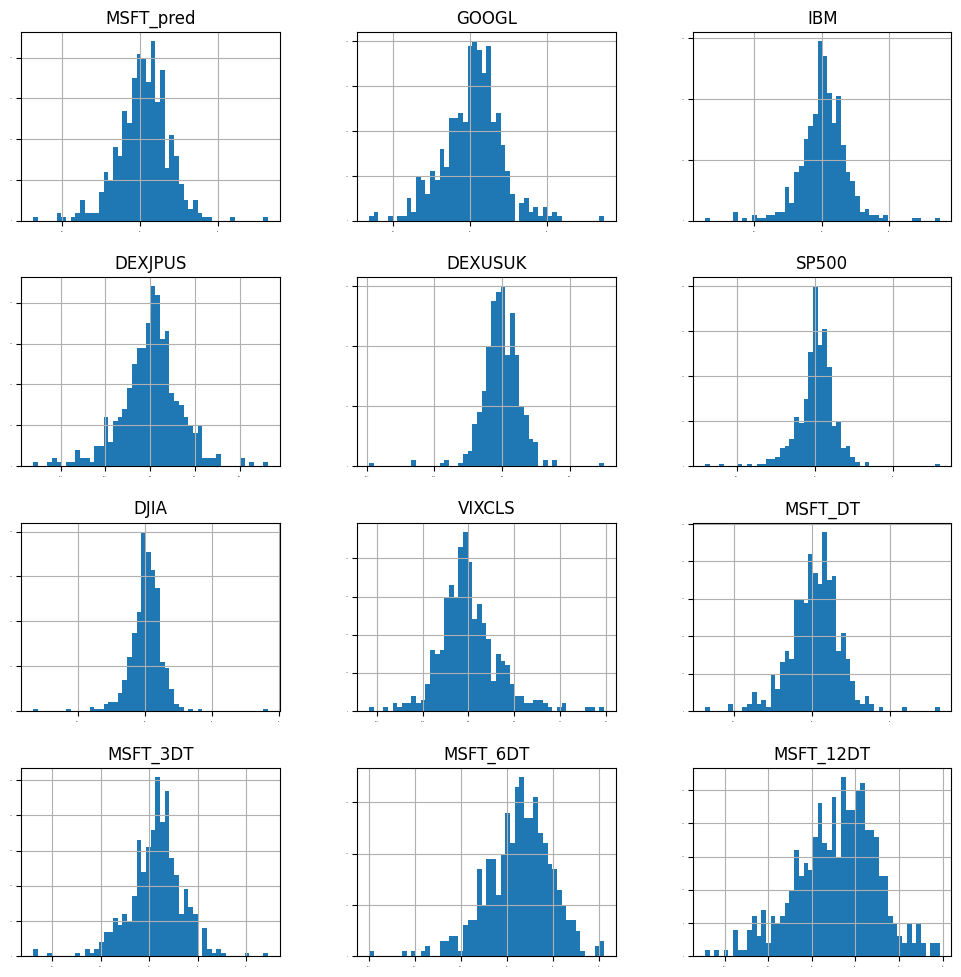

In [54]:
dataset.hist(bins=50, sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(12,12))
pyplot.show()

The above histogram shows the distribution for each series individually. Next, lets look at the density distribution over the same x axis scale.

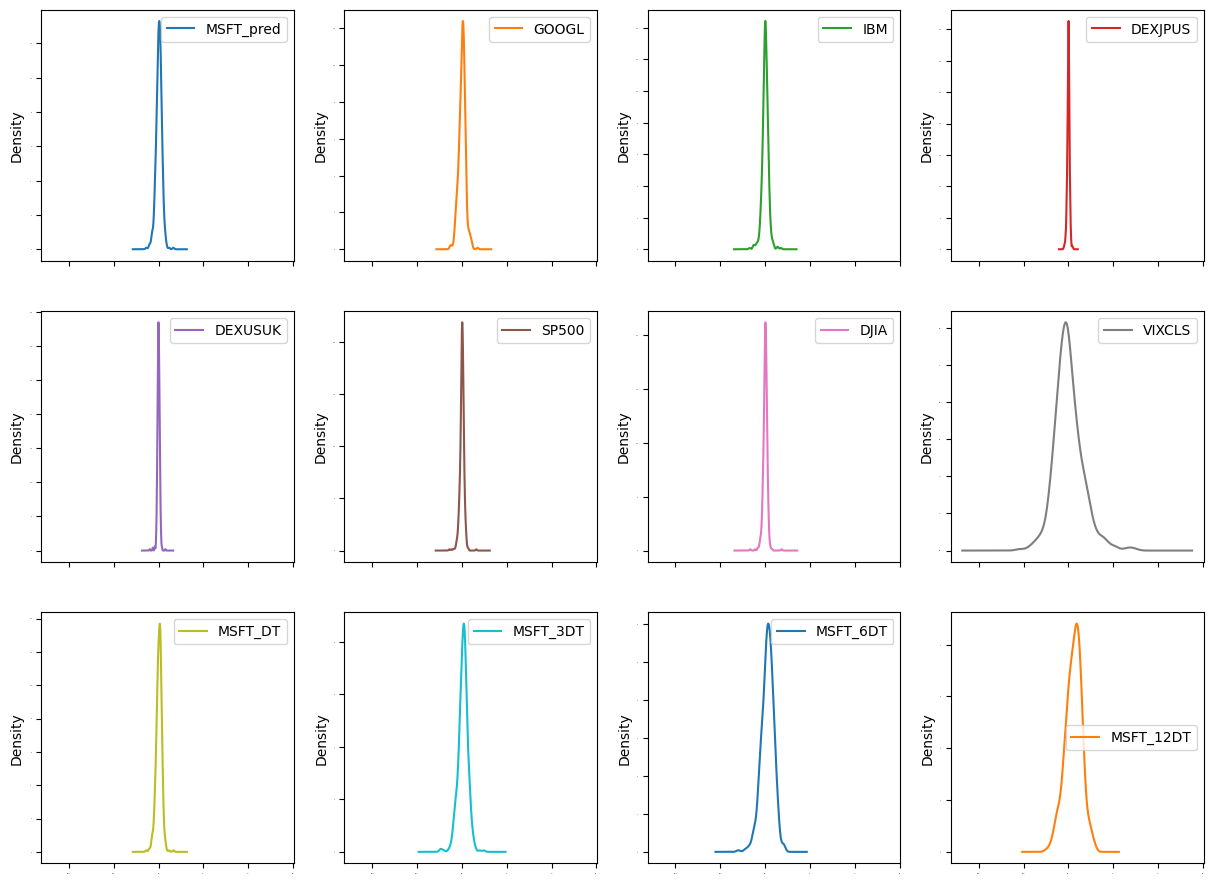

In [55]:
dataset.plot(kind='density', subplots=True, layout=(4,4), sharex=True, legend=True, fontsize=1, figsize=(15,15))
pyplot.show()

We can see that the vix has a much larger variance compared to the other distributions.

In order to get a sense of the interdependence of the data we look at the scatter plot and the correlation matrix

<Axes: title={'center': 'Correlation Matrix'}>

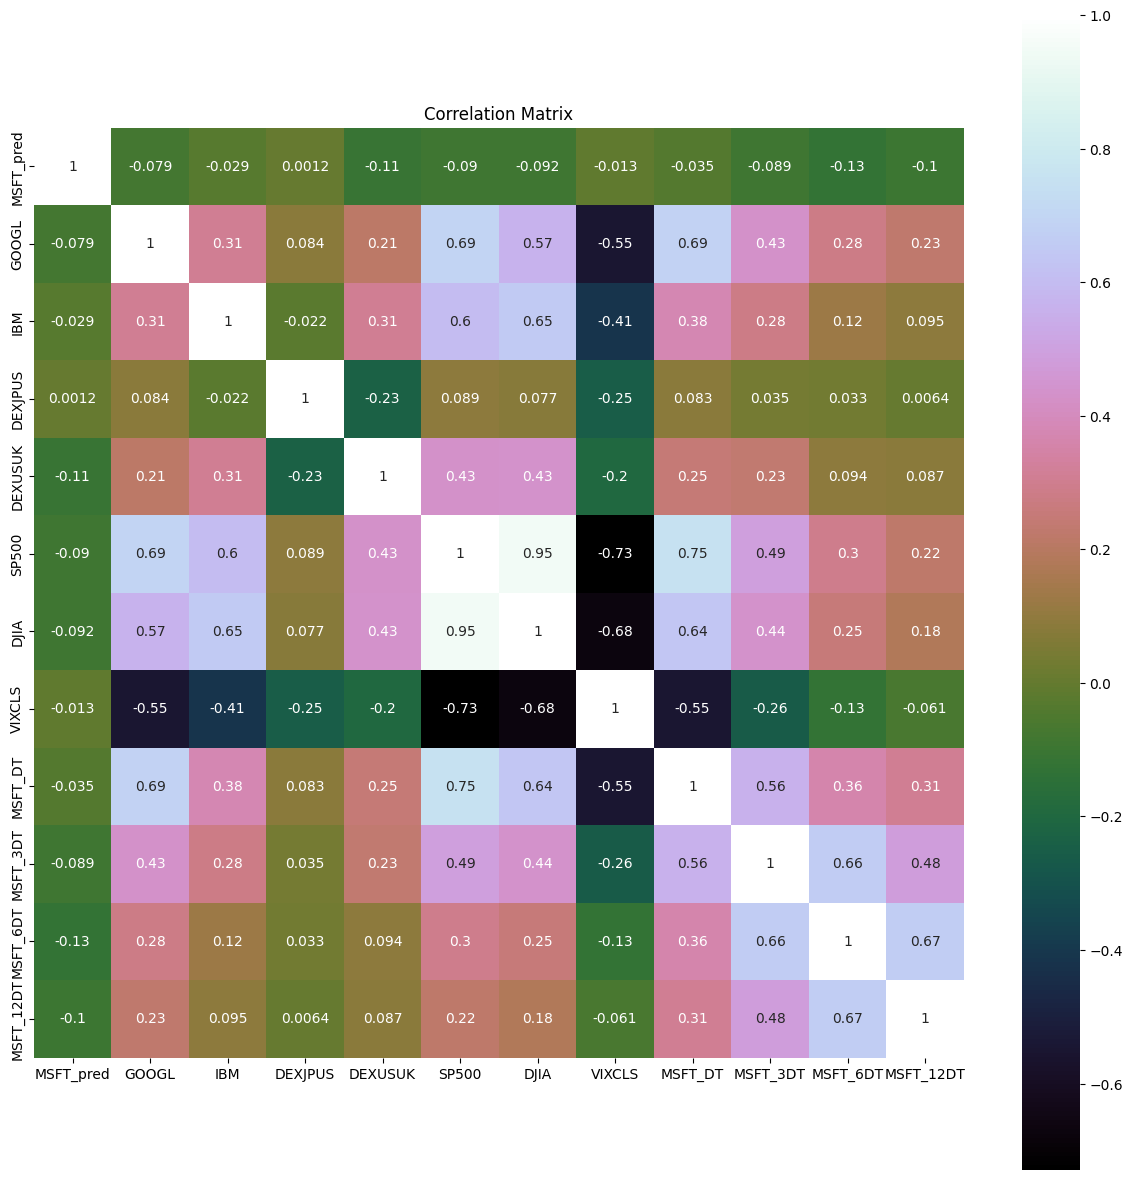

In [56]:
correlation = dataset.corr()
pyplot.figure(figsize=(15,15))
pyplot.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='cubehelix')

Looking at the correlation plot above, we see some correlation of the predicted vari‐
able with the lagged 5 days, 15days, 30 days and 60 days return of MSFT. 

<Figure size 1500x1500 with 0 Axes>

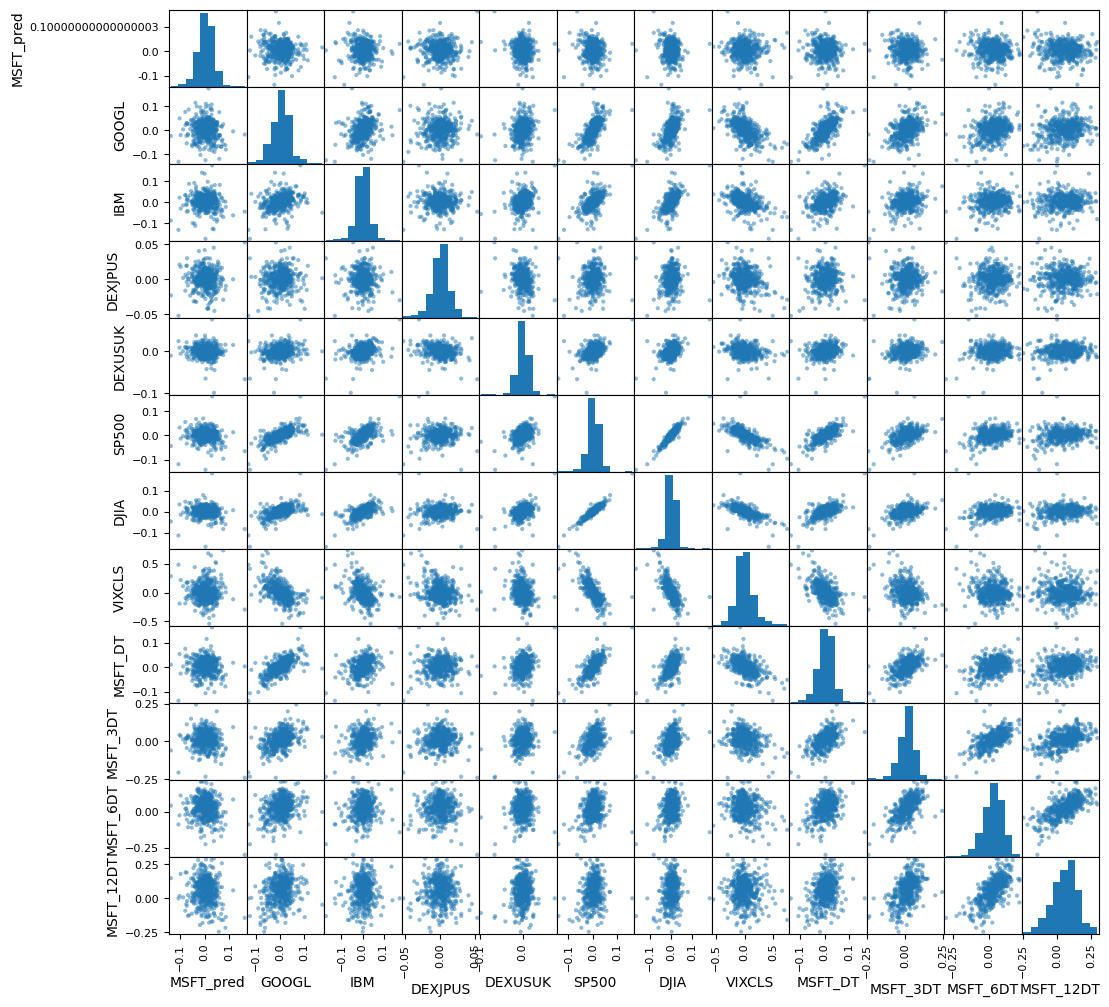

In [57]:
pyplot.figure(figsize=(15,15))
scatter_matrix(dataset,figsize=(12,12))
pyplot.show()

Looking at the scatter plot above, we see some linear relationship of the predicted
variable the lagged 15 days, 30 days and 60 days return of MSFT. [I doubt this claim]

<a id='2.3'></a>
## 3.3. Time Series Analysis 

Next, we look at the seasonal decomposition of our time series

In [59]:
Y.head()

2015-06-08   -0.005
2015-06-15    0.016
2015-06-22   -0.041
2015-06-29   -0.002
2015-07-07    0.029
Name: MSFT_pred, dtype: float64

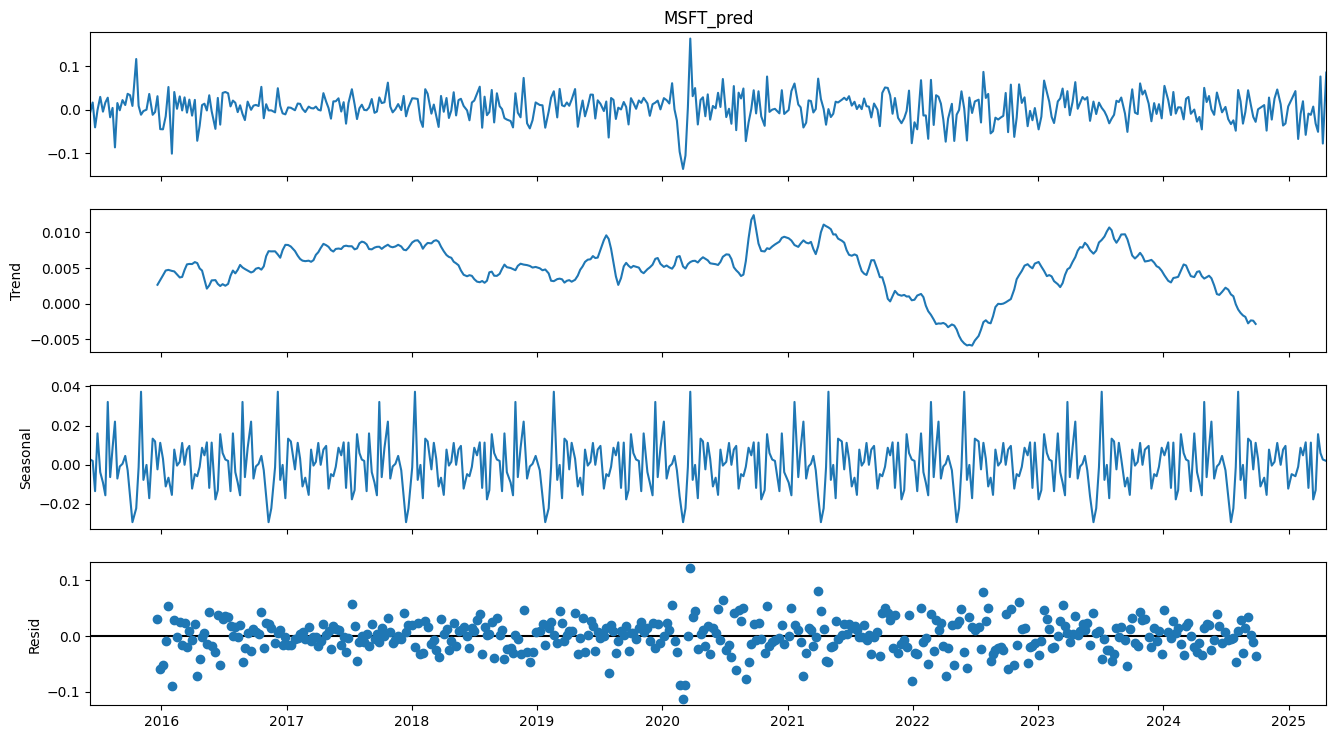

In [58]:
res = sm.tsa.seasonal_decompose(Y, period=52)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
pyplot.show()

We can see that for MSFT there is a big dip in 2022.

<a id='3'></a>
## 4. Data Preparation

<a id='3.2'></a>
## 4.2. Feature Selection

We use sklearn's SelectKBest function to get a sense of feature importance. 

In [70]:
bestfeatures = SelectKBest(k=5, score_func=f_regression)
fit = bestfeatures.fit(X,Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
featureScores.nlargest(10,'Score').set_index('Specs')  #print 10 best features

,Score
Specs,
MSFT_6DT,7.564
DEXUSUK,5.617
MSFT_12DT,4.755
DJIA,3.981
SP500,3.804
MSFT_3DT,3.771
GOOGL,2.917
MSFT_DT,0.571
IBM,0.388


We see that MSFT_6DT seems to be the most important feature and vix being the least important.

<a id='4'></a>
# 5. Evaluate Algorithms and Models

<a id='4.1'></a>
## 5.1. Train Test Split and Evaluation Metrics

Next, we start by splitting our data in training and testing chunks. If we are going to use Time series models we have to split the data in continous series.

In [71]:
validation_size = 0.2

#In case the data is not dependent on the time series, then train and test split randomly
# seed = 7
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=validation_size, random_state=seed)

#In case the data is not dependent on the time series, then train and test split should be done based on sequential sample
#This can be done by selecting an arbitrary split point in the ordered list of observations and creating two new datasets.
train_size = int(len(X) * (1-validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

<a id='4.2'></a>
## 5.2. Test Options and Evaluation Metrics

In [72]:
num_folds = 10
seed = 7
# scikit is moving away from mean_squared_error. 
# In order to avoid confusion, and to allow comparison with other models, we invert the final scores
scoring = 'neg_mean_squared_error' 

<a id='4.3'></a>
## 5.3. Compare Models and Algorithms

<a id='4.3.1'></a>
### 5.3.1 Machine Learning models-from scikit-learn

##### Regression and Tree Regression algorithms

In [73]:
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

##### Neural Network algorithms

In [74]:
models.append(('MLP', MLPRegressor()))

##### Ensable Models

In [75]:
# Boosting methods
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))
# Bagging methods
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

Once we have selected all the models, we loop over each of them. First we run the K-fold analysis. Next we run the model on the entire training and testing dataset.

In [79]:
names = []
kfold_results = []
test_results = []
train_results = []
print('Model CV_mean, CV_std, Train_MSE, Test_MSE')
for name, model in models:
    names.append(name)
    
    ## K Fold analysis:
    
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    #converted mean square error to positive. The lower the beter
    cv_results = -1* cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)
    

    # Full Training period
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)
    
    # Test results
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)
    
    msg = "%s: %f (%f) %f %f" % (name, cv_results.mean(), cv_results.std(), train_result, test_result)
    # msg = f%s: %f (%f) %f %f" % (name, cv_results.mean(), cv_results.std(), train_result, test_result)
    
    print(msg)

Model CV_mean, CV_std, Train_MSE, Test_MSE
LR: 0.001143 (0.000157) 0.001039 0.000990
LASSO: 0.001096 (0.000165) 0.001091 0.000984
EN: 0.001096 (0.000165) 0.001091 0.000984
KNN: 0.001348 (0.000165) 0.000852 0.001130
CART: 0.002066 (0.000433) 0.000000 0.001768
SVR: 0.001176 (0.000239) 0.001055 0.001017
MLP: 0.001335 (0.000276) 0.001188 0.001249
ABR: 0.001195 (0.000258) 0.000814 0.000955
GBR: 0.001389 (0.000354) 0.000261 0.001089
RFR: 0.001235 (0.000295) 0.000165 0.000987
ETR: 0.001244 (0.000247) 0.000000 0.000966


#### K Fold results

We being by looking at the K Fold results

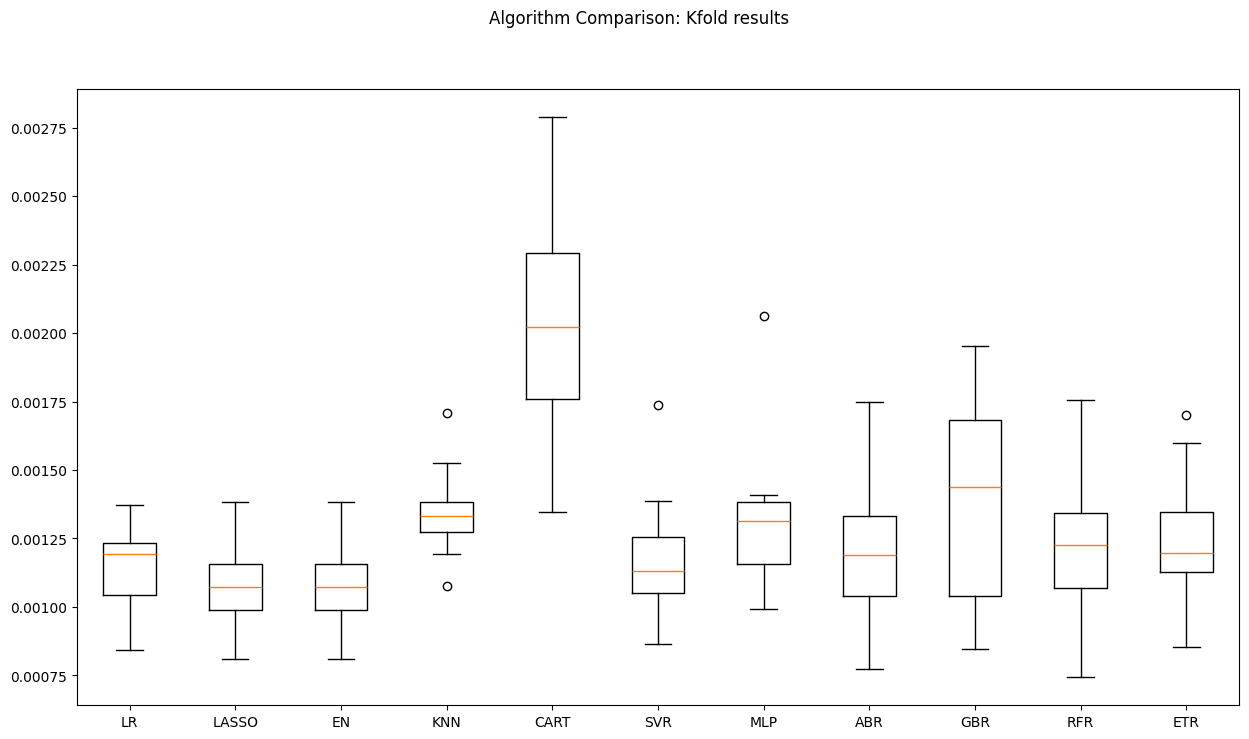

In [80]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison: Kfold results')
ax = fig.add_subplot(111)
pyplot.boxplot(kfold_results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()

We see the linear regression and the regularized regression including the Lasso regression (LASSO) and elastic net (EN) seem to do a good job.

#### Training and Test error

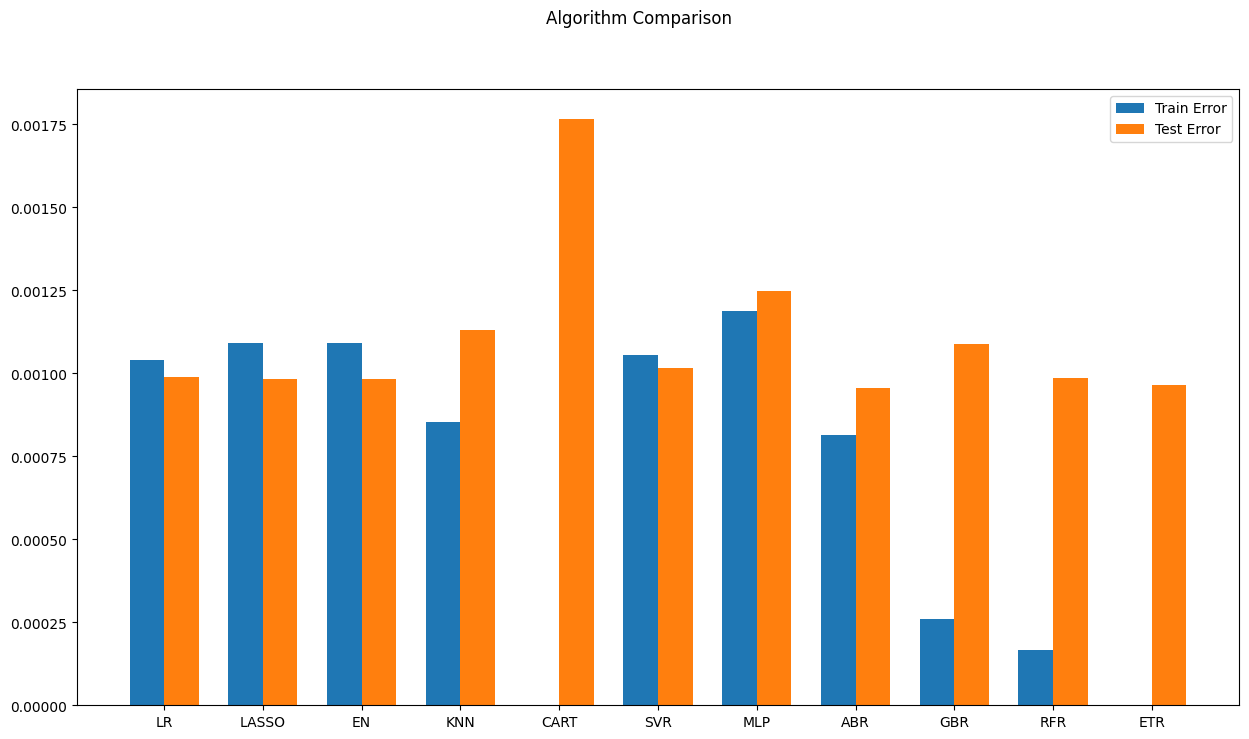

In [81]:
# compare algorithms
fig = pyplot.figure()

ind = np.arange(len(names))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

Looking at the training and test error, we still see a better performance of the linear models. Some of the algorithms, such as the decision tree regressor (CART) overfit on
the training data and produced very high error on the test set and these models
should be avoided. Ensemble models, such as gradient boosting regression (GBR) and
random forest regression (RFR) have low bias but high variance. We also see that the
artificial neural network (shown as MLP is the chart) algorithm shows higher errors
both in training set and test set, which is perhaps due to the linear relationship of the
variables not captured accurately by ANN or improper hyperparameters or insuffi‐
cient training of the model.

<a id='4.3.1'></a>
### 5.3.1 Time Series based models-ARIMA and LSTM

Let us first prepare the dataset for ARIMA models,
by having only the correlated varriables as exogenous variables.

### Time Series Model - ARIMA Model

In [85]:
X_train_ARIMA=X_train.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
X_test_ARIMA=X_test.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
tr_len = len(X_train_ARIMA)
te_len = len(X_test_ARIMA)
to_len = len (X)

In [86]:
modelARIMA=ARIMA(endog=Y_train,exog=X_train_ARIMA,order=[1,0,0])
model_fit = modelARIMA.fit()

In [110]:
error_Training_ARIMA = mean_squared_error(Y_train, model_fit.fittedvalues)
predicted = model_fit.predict(start = tr_len -1 ,end = to_len -1, exog = X_test_ARIMA)[1:]
error_Test_ARIMA = mean_squared_error(Y_test,predicted)
error_Test_ARIMA

0.0009288556195632398

###  LSTM Model

In [87]:
seq_len = 2 #Length of the seq for the LSTM

Y_train_LSTM, Y_test_LSTM = np.array(Y_train)[seq_len-1:], np.array(Y_test)
X_train_LSTM = np.zeros((X_train.shape[0]+1-seq_len, seq_len, X_train.shape[1]))
X_test_LSTM = np.zeros((X_test.shape[0], seq_len, X.shape[1]))
for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i:X_train.shape[0]+i+1-seq_len, :]
    X_test_LSTM[:, i, :] = np.array(X)[X_train.shape[0]+i-1:X.shape[0]+i+1-seq_len, :]


In [98]:
# Lstm Network
def create_LSTMmodel(neurons=12, learn_rate = 0.01, momentum=0):
        # create model
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
    #More number of cells can be added if needed 
    model.add(Dense(1))
    # optimizer = SGD(learn_rater=learn_rate, momentum=momentum)
    model.compile(loss='mse', optimizer='adam')
    return model
LSTMModel = create_LSTMmodel(24, learn_rate = 0.01, momentum=0)
LSTMModel_fit = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data=(X_test_LSTM, Y_test_LSTM),epochs=330, batch_size=72, verbose=0, shuffle=False)

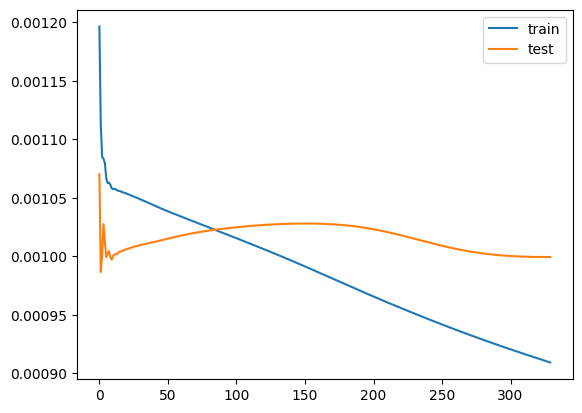

In [99]:
#Visual plot to check if the error is reducing
pyplot.plot(LSTMModel_fit.history['loss'], label='train')
pyplot.plot(LSTMModel_fit.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

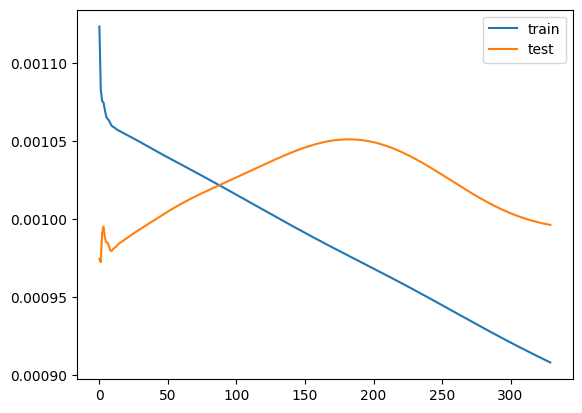

In [107]:
# If we use only 12 neurons, the result looks like this:
display(Image(filename='../../images/stock_lstm_12neurons.png'))

In [108]:
error_Training_LSTM = mean_squared_error(Y_train_LSTM, LSTMModel.predict(X_train_LSTM))
predicted = LSTMModel.predict(X_test_LSTM)
error_Test_LSTM = mean_squared_error(Y_test,predicted)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


#### Append to previous results

In [111]:
test_results.append(error_Test_ARIMA)
test_results.append(error_Test_LSTM)

train_results.append(error_Training_ARIMA)
train_results.append(error_Training_LSTM)

names.append("ARIMA")
names.append("LSTM")

## Overall Comparison of all the algorithms ( including Time Series Algorithms)

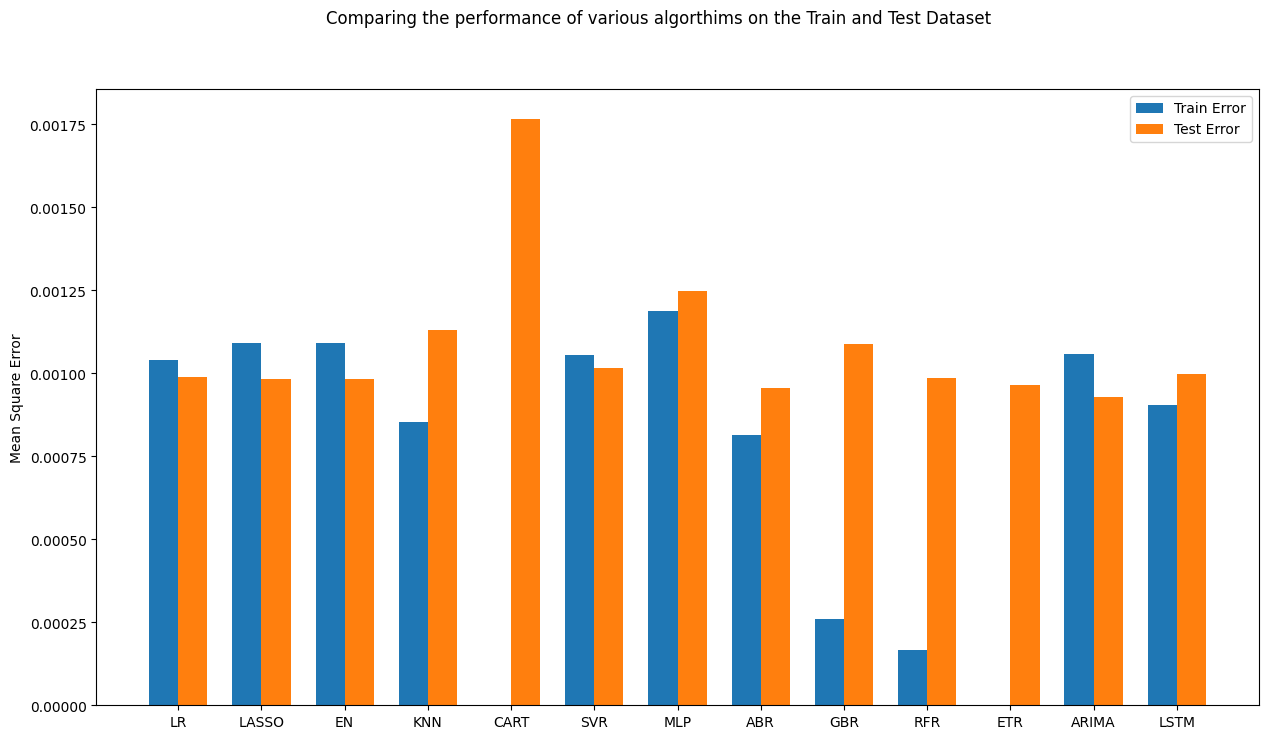

In [112]:
# compare algorithms
fig = pyplot.figure()

ind = np.arange(len(names))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle('Comparing the performance of various algorthims on the Train and Test Dataset')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.ylabel('Mean Square Error')
pyplot.show()

Looking at the chart above, we find time series based ARIMA model comparable to
the linear supervised-regression models such as Linear Regression (LR), Lasso Regres‐
sion (LASSO) and Elastic Net (EN). This can primarily be due to the strong linear
relationship as discussed before. The LSTM model performs decently, however,
ARIMA model outperforms the LSTM model in the test set. Hence, we select the
ARIMA model for the model tuning.

<a id='5'></a>
# 6. Model Tuning and Grid Search

As shown in the chart above the ARIMA model is one of the best mode, so we perform the model tuning of the ARIMA model. The default order of ARIMA model is [1,0,0]. We perform a grid search with different combination p,d and q in the ARIMA model's order.  

In [113]:
#Grid Search for ARIMA Model
#Change p,d and q and check for the best result

# evaluate an ARIMA model for a given order (p,d,q)
#Assuming that the train and Test Data is already defined before
def evaluate_arima_model(arima_order):
    #predicted = list()     
    modelARIMA=ARIMA(endog=Y_train,exog=X_train_ARIMA,order=arima_order)
    model_fit = modelARIMA.fit()
    error = mean_squared_error(Y_train, model_fit.fittedvalues)
    return error
 
# evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(p_values, d_values, q_values): 
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)                
                try:
                    mse = evaluate_arima_model(order)                    
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print('ARIMA%s MSE=%.7f' % (order,mse))
                except:
                    continue
    print('Best ARIMA%s MSE=%.7f' % (best_cfg, best_score))
    
# evaluate parameters
p_values = [0, 1, 2]
d_values = range(0, 2)
q_values = range(0, 2)
warnings.filterwarnings("ignore")
evaluate_models(p_values, d_values, q_values)   

ARIMA(0, 0, 0) MSE=0.0010677
ARIMA(0, 0, 1) MSE=0.0010600
ARIMA(0, 1, 0) MSE=0.0016782
ARIMA(0, 1, 1) MSE=0.0010844
ARIMA(1, 0, 0) MSE=0.0010591
ARIMA(1, 0, 1) MSE=0.0010634
ARIMA(1, 1, 0) MSE=0.0015064
ARIMA(1, 1, 1) MSE=0.0011104
ARIMA(2, 0, 0) MSE=0.0010592
ARIMA(2, 0, 1) MSE=0.0010589
ARIMA(2, 1, 0) MSE=0.0014428
ARIMA(2, 1, 1) MSE=0.0011012
Best ARIMA(2, 0, 1) MSE=0.0010589


<a id='6'></a>
# 7. Finalise the Model

<a id='6.1'></a>
## 7.1. Results on the Test Dataset

In [114]:
# prepare model
modelARIMA_tuned=ARIMA(endog=Y_train,exog=X_train_ARIMA,order=[2,0,1])
model_fit_tuned = modelARIMA_tuned.fit()

In [115]:
# estimate accuracy on validation set
predicted_tuned = model_fit.predict(start = tr_len -1 ,end = to_len -1, exog = X_test_ARIMA)[1:]
print(mean_squared_error(Y_test,predicted_tuned))

0.0009288556195632398


After tuning the model and picking the best ARIMA model or the order 2,0 and 1 we select this model and can it can be used for the modeling purpose. 

<a id='6.2'></a>
## 7.2. Save Model for Later Use

In [116]:
# Save Model Using Pickle
from pickle import dump
from pickle import load

# save the model to disk
filename = 'finalized_model.sav'
dump(model_fit_tuned, open(filename, 'wb'))

In [117]:
#Use the following code to produce the comparison of actual vs. predicted
# predicted_tuned.index = Y_test.index
# pyplot.plot(np.exp(Y_test).cumprod(), 'r') # plotting t, a separately
# pyplot.plot(np.exp(predicted_tuned).cumprod(), 'b')
# pyplot.rcParams["figure.figsize"] = (8,5)
# pyplot.show()

### Summary

We can conclude that simple models - linear regression, regularized regression (i.e.
Lasso and elastic net) - along with the time series model such as ARIMA are promis‐
ing modelling approaches for asset price prediction problem. These models can
enable financial practitioners to model time dependencies with a very flexible
approach. The overall approach presented in this case study may help us encounter
overfitting and underfitting which are some of the key challenges in the prediction
problem in finance.
We should also note that we can use better set of indicators, such as P/E ratio, trading
volume, technical indicators or news data, which might lead to better results. We will
demonstrate this in some of the case studies in the book.
Overall, we created a supervised-regression and time series modelling framework
which allows us to perform asset class prediction using historical data to generate
results and analyze risk and profitability before risking any actual capital.